# Simulation Validation: PCA-based Data Generation

This notebook validates the PCA simulation method (`dat_generator_pca`) across two
complementary dimensions.

---

## Part 1 — Real-data fidelity

Does simulated data reproduce the statistical properties of the real datasets it was
generated from?

| Property | Metric |
|---|---|
| **Feature mean distribution** | KS statistic + p-value comparing the *distribution* of per-feature means |
| **Feature variance distribution** | KS statistic + p-value comparing the *distribution* of per-feature variances |
| **Pairwise correlation distribution** | KS statistic + p-value comparing the *distribution* of pairwise correlations |
| **Marginal distributions** | Mean KS statistic across per-feature marginal tests; % features passing |
| **Correlation matrix distance** | Frobenius norm ‖R_real − R_sim‖_F / p |

KS statistics compare distributions directly without requiring feature-to-feature
alignment between real and simulated data.

---

## Part 2 — Design validation

Does the shared-loadings simulation design have the intended structural properties
required for transfer learning experiments?

| Property | Check |
|---|---|
| **Domain shift** | Target PC scores have nonzero mean µ_T encoding covariate shift |
| **Shared latent space** | Source and target scores occupy overlapping but shifted regions of V_src space |
| **Response coherence** | Response is predictable from features for both domains (non-trivial R²) |

## Imports and settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from scipy.linalg import norm
from itertools import product
from sklearn.decomposition import PCA as skPCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, roc_auc_score

from omicstl.simulation_utils.data_generation import generate_synth_data_pca, generate_pca_response

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = {'source': '#1976D2', 'target': '#E64A19'}
REAL_COLOR = '#555555'

## Load real datasets

Both files should contain feature-only matrices (no response column) with samples
as rows and features as columns.

In [2]:
source_real = pd.read_csv("data/source_dset.csv", index_col=0)
target_real = pd.read_csv("data/target_dset.csv", index_col=0)

# If a response column is present (named 'response' or first column is non-numeric),
# drop it so we work with features only.
for _name, _df in [("source", source_real), ("target", target_real)]:
    if "response" in _df.columns:
        _df.drop(columns=["response"], inplace=True)

print(f"Source real:  {source_real.shape[0]} samples × {source_real.shape[1]} features")
print(f"Target real:  {target_real.shape[0]} samples × {target_real.shape[1]} features")
display(source_real.describe().loc[["mean", "std"]].round(3))

Source real:  358 samples × 476 features
Target real:  240 samples × 476 features


,RS30_HUMAN,EIF3I_HUMAN,RL24_HUMAN,ARPC2_HUMAN,RUVB1_HUMAN,TEBP_HUMAN,PPGB_HUMAN,KPYM_HUMAN,PRDX5_HUMAN,PDIA1_HUMAN,...,RL30_HUMAN,TMM43_HUMAN,SMD3_HUMAN,VDAC2_HUMAN,RL27A_HUMAN,RAB5C_HUMAN,CPNE1_HUMAN,SRSF3_HUMAN,FKB1A_HUMAN,SC61B_HUMAN
mean,1.345,0.733,2.271,1.461,1.050,2.821,0.532,6.464,3.356,4.204,...,3.380,1.082,2.148,4.119,3.224,1.166,1.053,2.490,3.976,1.256
std,1.201,0.663,1.108,1.085,0.747,0.912,0.939,1.699,1.633,0.521,...,0.853,0.608,0.725,0.592,0.594,0.687,1.711,1.284,1.713,1.299


## Simulation grid

We vary:
- **n_source** – number of simulated source samples
- **n_target** – number of simulated target samples

All Part 1 fidelity scenarios use **α = 1.0** so the synthetic target reproduces the full observed target distribution.
Part 2 design checks compare **α = 0** (no domain shift) against **α = 1** (full observed shift).
SNR = 1 is used for continuous responses throughout.

In [3]:
n_source_list = [200]
n_target_list = [10, 25, 50, 100]

# alpha fixed for fidelity: reproduce the full observed target distribution
FIDELITY_ALPHA = 1.0

scenarios = [
    {"n_source": ns, "n_target": nt, "label": f"ns={ns} nt={nt}"}
    for ns, nt in product(n_source_list, n_target_list)
]
print(f"{len(scenarios)} scenarios defined")
pd.DataFrame(scenarios)

4 scenarios defined


,n_source,n_target,label
0,200,10,ns=200 nt=10
1,200,25,ns=200 nt=25
2,200,50,ns=200 nt=50
3,200,100,ns=200 nt=100


## Statistical helper functions

In [4]:
def align(real_df: pd.DataFrame, sim_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Align on common columns (Option A) or positionally (Option B)."""
    common = [c for c in sim_df.columns if c in real_df.columns]
    if common:
        return real_df[common], sim_df[common]
    return real_df.iloc[:, :sim_df.shape[1]], sim_df


def compute_stats(real_df: pd.DataFrame, sim_df: pd.DataFrame) -> dict:
    """Compare real vs simulated using distribution-level KS tests.

    KS tests compare the *distribution* of per-feature means, variances, and
    pairwise correlations — no feature-to-feature alignment required.
    """
    real = real_df.values.astype(float)
    sim  = sim_df.values.astype(float)
    p    = real.shape[1]

    real_means = real.mean(axis=0)
    sim_means  = sim.mean(axis=0)
    real_vars  = real.var(axis=0, ddof=1)
    sim_vars   = sim.var(axis=0, ddof=1)

    # Per-feature marginal KS (each feature's full distribution)
    feat_ks      = [ks_2samp(real[:, j], sim[:, j]) for j in range(p)]
    feat_ks_stat = np.array([r.statistic for r in feat_ks])
    feat_ks_pval = np.array([r.pvalue   for r in feat_ks])

    # Correlation upper triangles
    real_cor = np.corrcoef(real, rowvar=False)
    sim_cor  = np.corrcoef(sim,  rowvar=False)
    tri      = np.triu_indices(p, k=1)
    real_tri = real_cor[tri]
    sim_tri  = sim_cor[tri]

    # Distribution-level KS: does the simulation reproduce the same
    # *spread / shape* of means / variances / correlations across features?
    mean_ks = ks_2samp(real_means, sim_means)
    var_ks  = ks_2samp(real_vars,  sim_vars)
    cor_ks  = ks_2samp(real_tri,   sim_tri)

    frob = norm(real_cor - sim_cor, 'fro') / p

    return dict(
        # raw arrays for plotting
        real_means=real_means, sim_means=sim_means,
        real_vars=real_vars,   sim_vars=sim_vars,
        real_tri=real_tri,     sim_tri=sim_tri,
        real_cor=real_cor,     sim_cor=sim_cor,
        # per-feature marginal KS
        ks_stats=feat_ks_stat, ks_pvals=feat_ks_pval,
        feat_ks_mean=feat_ks_stat.mean(),
        frac_pass=np.mean(feat_ks_pval > 0.05),
        # distribution-level KS (primary metrics)
        mean_ks=mean_ks.statistic, mean_ks_p=mean_ks.pvalue,
        var_ks=var_ks.statistic,   var_ks_p=var_ks.pvalue,
        cor_ks=cor_ks.statistic,   cor_ks_p=cor_ks.pvalue,
        frob=frob,
    )

## Run simulations

For each scenario we:
1. Simulate paired source and target data using `generate_synth_data_pca`.
2. Align simulated features to the corresponding real features.
3. Compute all comparison statistics.

In [5]:
records = []

for sc in scenarios:
    ns, nt, lbl = sc["n_source"], sc["n_target"], sc["label"]
    print(f"Simulating {lbl} ...", end=" ", flush=True)

    synth_src, synth_tgt, src_scores, tgt_scores = generate_synth_data_pca(
        source_data=source_real,
        target_data=target_real,
        n_output_samps_source=ns,
        n_output_samps_target=nt,
        alpha=FIDELITY_ALPHA,
    )

    real_src_al, synth_src_al = align(source_real, synth_src)
    real_tgt_al, synth_tgt_al = align(target_real, synth_tgt)

    src_stats = compute_stats(real_src_al, synth_src_al)
    tgt_stats = compute_stats(real_tgt_al, synth_tgt_al)

    mu_tgt   = tgt_scores.mean(axis=0)
    mu_shift = float(np.linalg.norm(mu_tgt))

    records.append({
        **sc,
        "src_stats":  src_stats,    "tgt_stats":  tgt_stats,
        "synth_src":  synth_src_al, "synth_tgt":  synth_tgt_al,
        "real_src":   real_src_al,  "real_tgt":   real_tgt_al,
        "src_scores": src_scores,   "tgt_scores": tgt_scores,
        "mu_shift":   mu_shift,
    })
    print(
        f"src: mean_ks={src_stats['mean_ks']:.3f} var_ks={src_stats['var_ks']:.3f} "
        f"cor_ks={src_stats['cor_ks']:.3f}  |  "
        f"tgt: mean_ks={tgt_stats['mean_ks']:.3f} var_ks={tgt_stats['var_ks']:.3f} "
        f"cor_ks={tgt_stats['cor_ks']:.3f}  |  "
        f"‖µ_T‖={mu_shift:.3f}"
    )

print("\nAll simulations complete.")

Simulating ns=200 nt=10 ... src: mean_ks=0.015 var_ks=0.339 cor_ks=0.206  |  tgt: mean_ks=0.619 var_ks=0.981 cor_ks=0.218  |  ‖µ_T‖=12.949
Simulating ns=200 nt=25 ... src: mean_ks=0.021 var_ks=0.358 cor_ks=0.193  |  tgt: mean_ks=0.621 var_ks=0.971 cor_ks=0.273  |  ‖µ_T‖=13.144
Simulating ns=200 nt=50 ... src: mean_ks=0.021 var_ks=0.343 cor_ks=0.207  |  tgt: mean_ks=0.621 var_ks=0.983 cor_ks=0.211  |  ‖µ_T‖=12.942
Simulating ns=200 nt=100 ... src: mean_ks=0.013 var_ks=0.301 cor_ks=0.207  |  tgt: mean_ks=0.621 var_ks=0.981 cor_ks=0.211  |  ‖µ_T‖=12.828

All simulations complete.


---
## Part 1: Real-data fidelity

The following sections compare simulated features against the real data they were
generated from, across means, variances, pairwise correlations, and marginal
distributions.  Results are reported for both source and target domains across all
simulation scenarios.

## Summary metrics table

In [6]:
def fmt_p(p):
    if p < 0.001: return "<0.001"
    return f"{p:.3f}"

rows = []
for rec in records:
    for domain, key in [("source", "src_stats"), ("target", "tgt_stats")]:
        s = rec[key]
        rows.append({
            "n_source": rec["n_source"], "n_target": rec["n_target"], "p": rec["p"],
            "domain":        domain,
            "mean KS":       round(s["mean_ks"],    3),
            "mean KS p":     fmt_p(s["mean_ks_p"]),
            "var KS":        round(s["var_ks"],     3),
            "var KS p":      fmt_p(s["var_ks_p"]),
            "cor KS":        round(s["cor_ks"],     3),
            "cor KS p":      fmt_p(s["cor_ks_p"]),
            "Frob/p":        round(s["frob"],       3),
            "feat KS (mean)": round(s["feat_ks_mean"], 3),
            "% pass KS":     round(s["frac_pass"] * 100, 1),
        })

summary = pd.DataFrame(rows)
display(
    summary.style
    .background_gradient(subset=["mean KS", "var KS", "cor KS"], cmap="YlOrRd", vmin=0, vmax=1)
    .background_gradient(subset=["Frob/p", "feat KS (mean)"], cmap="YlOrRd")
    .background_gradient(subset=["% pass KS"], cmap="YlGn", vmin=0, vmax=100)
    .format(precision=3)
)

KeyError: 'p'

## Per-scenario diagnostic plots

Detailed scatter and density plots for a representative scenario.
Change `DIAG_IDX` to examine a different entry from the simulation grid.

In [7]:
# Pick a representative scenario for per-scenario diagnostic plots
DIAG_IDX = next(
    i for i, r in enumerate(records)
    if r["n_source"] == max(n_source_list)
    and r["n_target"] == sorted(n_target_list)[len(n_target_list) // 2]
)
rec = records[DIAG_IDX]
print(f"Diagnostic scenario: {rec['label']}")

panels = [
    ("Source", rec["src_stats"], PALETTE["source"]),
    ("Target", rec["tgt_stats"], PALETTE["target"]),
]

Diagnostic scenario: ns=200 nt=50


### Mean and variance fidelity

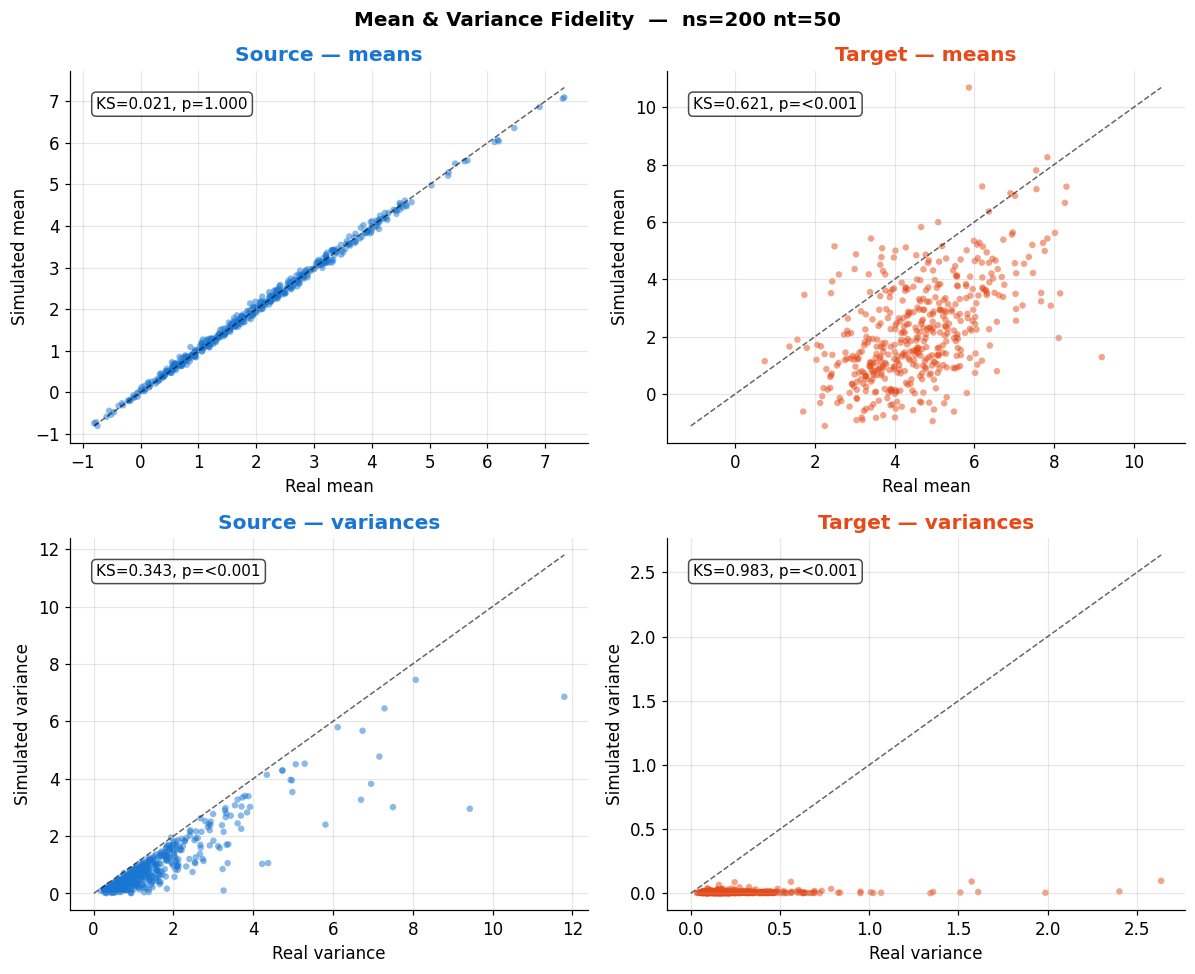

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle(f"Mean & Variance Fidelity  —  {rec['label']}", fontsize=13, fontweight='bold')

panels = [
    ("Source", rec["src_stats"], PALETTE["source"]),
    ("Target", rec["tgt_stats"], PALETTE["target"]),
]

for col, (domain, s, color) in enumerate(panels):
    for row, (stat, xlabel, ylabel, ks_key, ks_p_key) in enumerate([
        ("means", "Real mean",     "Simulated mean",     "mean_ks", "mean_ks_p"),
        ("vars",  "Real variance", "Simulated variance", "var_ks",  "var_ks_p"),
    ]):
        ax = axes[row, col]
        rx = s[f"real_{stat}"]
        sx = s[f"sim_{stat}"]
        ax.scatter(rx, sx, alpha=0.5, s=18, color=color, edgecolors='none')
        lims = [min(rx.min(), sx.min()), max(rx.max(), sx.max())]
        ax.plot(lims, lims, 'k--', lw=1, alpha=0.6, label='y = x')
        ks_val = s[ks_key]
        p_val  = s[ks_p_key]
        p_str  = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
        ax.text(0.05, 0.93, f"KS={ks_val:.3f}, p={p_str}", transform=ax.transAxes,
                fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(f"{domain} — {'means' if stat=='means' else 'variances'}",
                     fontweight='bold', color=color)

plt.tight_layout()
plt.show()

### Pairwise correlation distribution

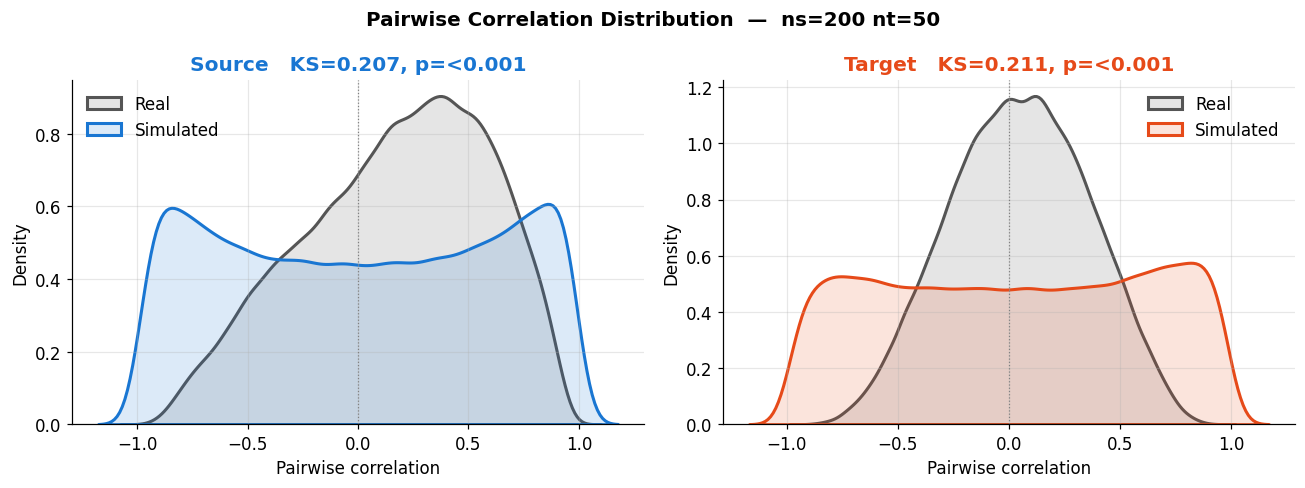

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f"Pairwise Correlation Distribution  —  {rec['label']}",
             fontsize=13, fontweight='bold')

for ax, (domain, s, color) in zip(axes, panels):
    sns.kdeplot(s["real_tri"], ax=ax, color=REAL_COLOR, lw=2, label="Real", fill=True, alpha=0.15)
    sns.kdeplot(s["sim_tri"],  ax=ax, color=color,      lw=2, label="Simulated", fill=True, alpha=0.15)
    p_str = "<0.001" if s["cor_ks_p"] < 0.001 else f"{s['cor_ks_p']:.3f}"
    ax.set_xlabel("Pairwise correlation")
    ax.set_ylabel("Density")
    ax.set_title(f"{domain}   KS={s['cor_ks']:.3f}, p={p_str}", fontweight='bold', color=color)
    ax.legend(frameon=False)
    ax.axvline(0, color='gray', lw=0.8, ls=':')

plt.tight_layout()
plt.show()

### Distribution overlays: means, variances, and correlations

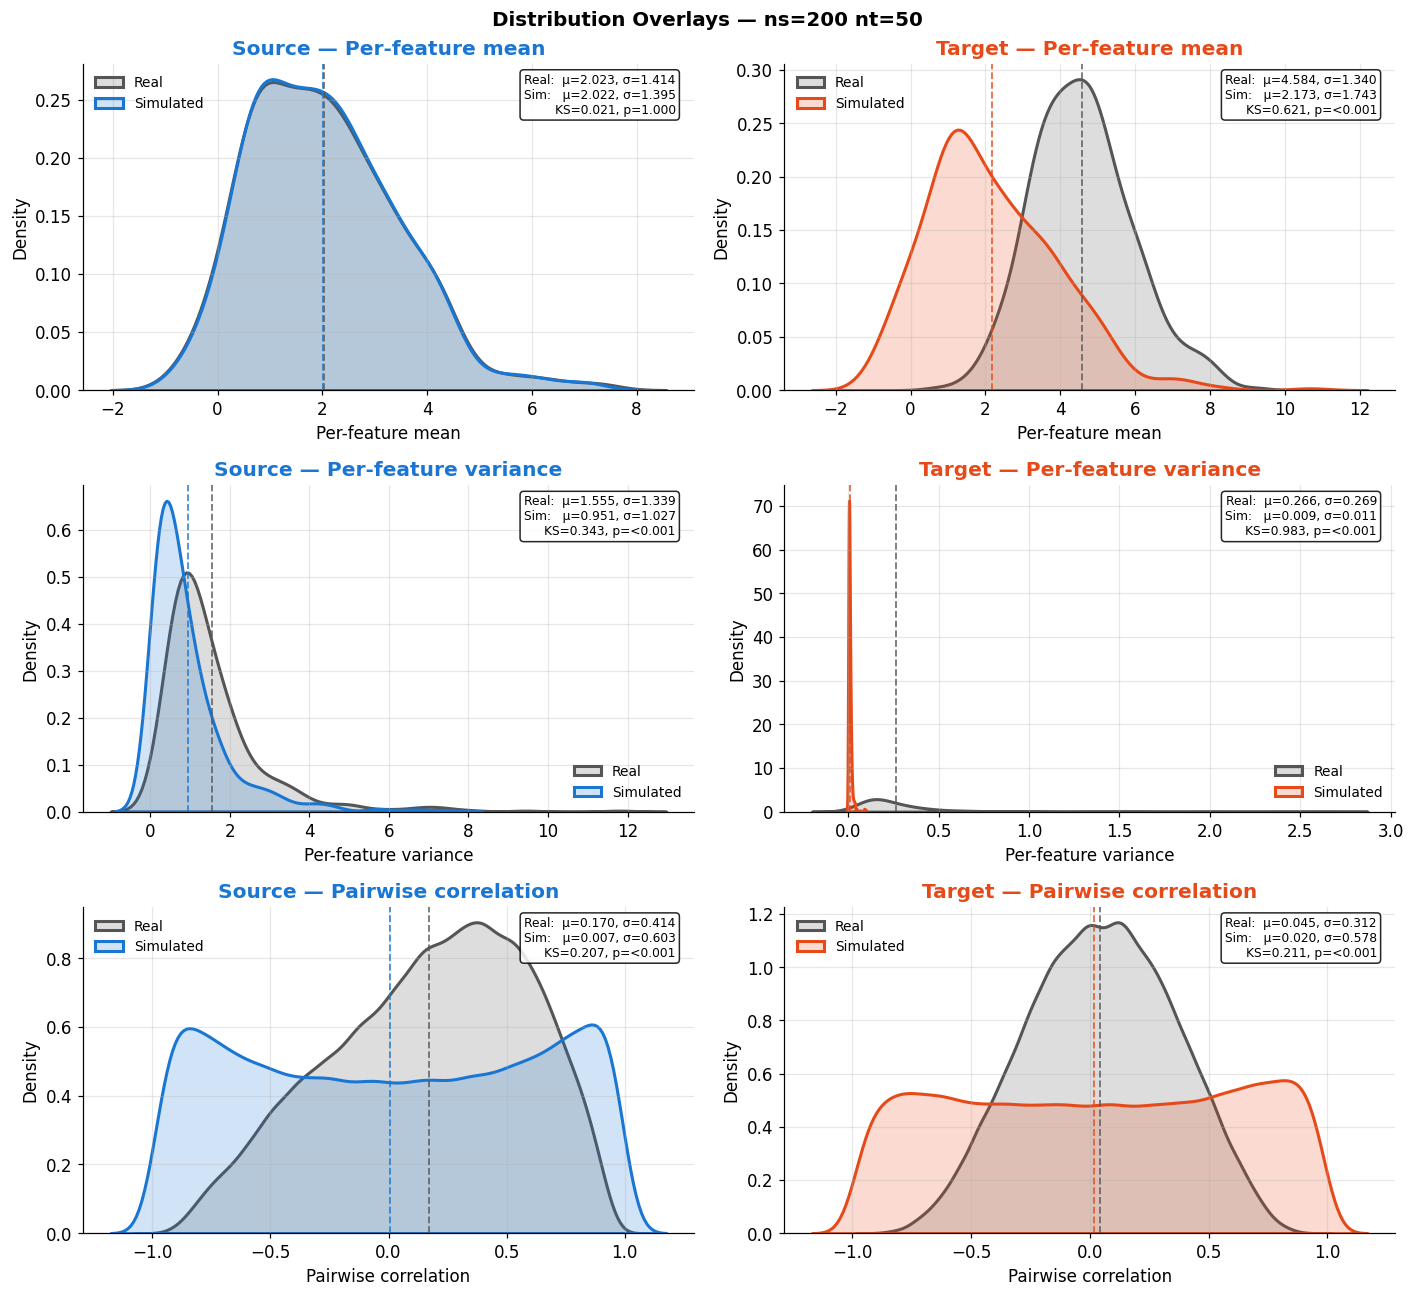

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle(f"Distribution Overlays — {rec['label']}", fontsize=13, fontweight='bold')

row_cfg = [
    ("Per-feature mean",     "real_means", "sim_means", "mean_ks", "mean_ks_p"),
    ("Per-feature variance", "real_vars",  "sim_vars",  "var_ks",  "var_ks_p"),
    ("Pairwise correlation", "real_tri",   "sim_tri",   "cor_ks",  "cor_ks_p"),
]

for row_idx, (xlabel, real_key, sim_key, ks_key, p_key) in enumerate(row_cfg):
    for col_idx, (domain, s, color) in enumerate(panels):
        ax = axes[row_idx, col_idx]
        real_vals = s[real_key]
        sim_vals  = s[sim_key]

        sns.kdeplot(real_vals, ax=ax, color=REAL_COLOR, lw=2,
                    label="Real", fill=True, alpha=0.20)
        sns.kdeplot(sim_vals,  ax=ax, color=color, lw=2,
                    label="Simulated", fill=True, alpha=0.20)

        ax.axvline(np.mean(real_vals), color=REAL_COLOR, lw=1.2, ls='--', alpha=0.8)
        ax.axvline(np.mean(sim_vals),  color=color,      lw=1.2, ls='--', alpha=0.8)

        ks_val = s[ks_key]
        p_val  = s[p_key]
        p_str  = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
        stats_txt = (
            f"Real:  μ={np.mean(real_vals):.3f}, σ={np.std(real_vals):.3f}\n"
            f"Sim:   μ={np.mean(sim_vals):.3f}, σ={np.std(sim_vals):.3f}\n"
            f"KS={ks_val:.3f}, p={p_str}"
        )
        ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
                fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.set_title(f"{domain} — {xlabel}", fontweight='bold', color=color)
        ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

### Correlation matrix heatmaps

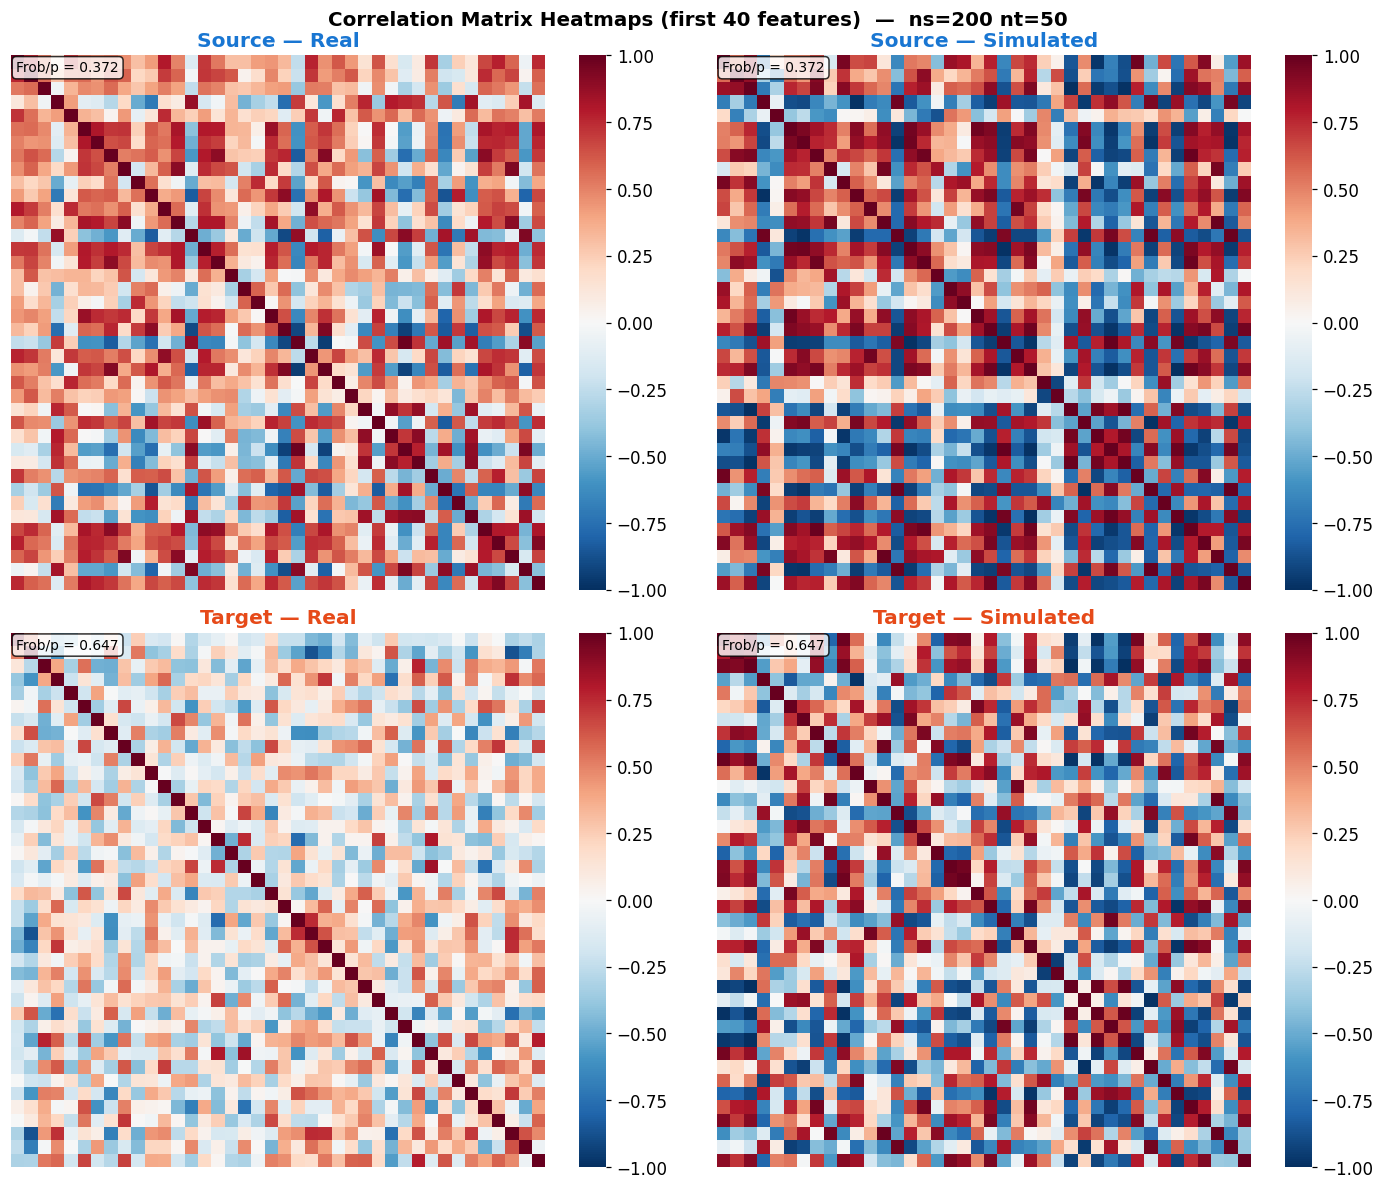

In [11]:
HMAP_FEATS = 40   # show top N features for readability

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle(f"Correlation Matrix Heatmaps (first {HMAP_FEATS} features)  —  {rec['label']}",
             fontsize=13, fontweight='bold')

hmap_kwargs = dict(vmin=-1, vmax=1, cmap="RdBu_r", square=True,
                   xticklabels=False, yticklabels=False, cbar=True)

for row, (domain, s, color) in enumerate(panels):
    nf = min(HMAP_FEATS, s["real_cor"].shape[0])
    for col, (label, mat) in enumerate([
        ("Real",      s["real_cor"][:nf, :nf]),
        ("Simulated", s["sim_cor"] [:nf, :nf]),
    ]):
        ax = axes[row, col]
        sns.heatmap(mat, ax=ax, **hmap_kwargs)
        ax.set_title(f"{domain} — {label}", fontweight='bold', color=color)
        ax.text(0.01, 0.99, f"Frob/p = {s['frob']:.3f}", transform=ax.transAxes,
                fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### KS test: per-feature distributional fidelity

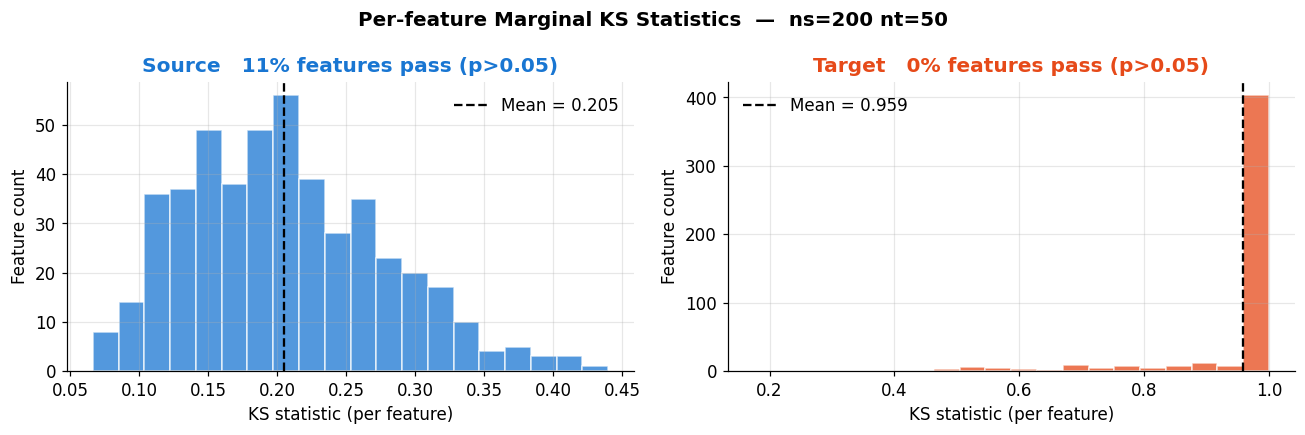

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Per-feature Marginal KS Statistics  —  {rec['label']}",
             fontsize=13, fontweight='bold')

for ax, (domain, s, color) in zip(axes, panels):
    ax.hist(s["ks_stats"], bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(s["feat_ks_mean"], color='black', lw=1.5, ls='--',
               label=f"Mean = {s['feat_ks_mean']:.3f}")
    ax.set_xlabel("KS statistic (per feature)")
    ax.set_ylabel("Feature count")
    ax.set_title(f"{domain}   {s['frac_pass']*100:.0f}% features pass (p>0.05)",
                 fontweight='bold', color=color)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### PCA alignment: do simulated samples occupy the same latent space?

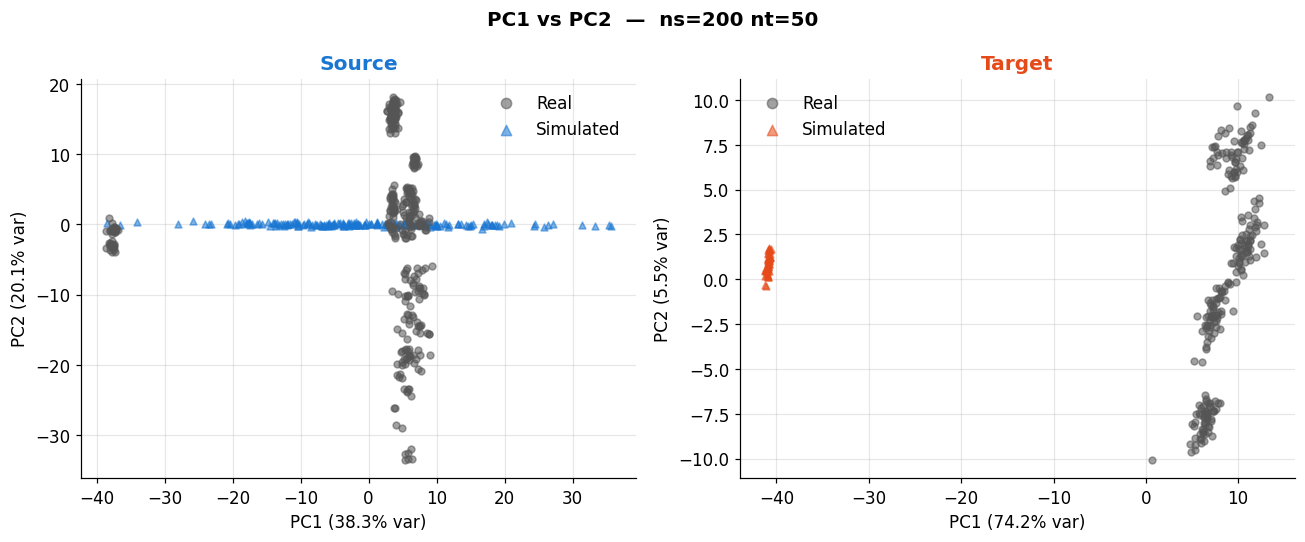

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"PC1 vs PC2  —  {rec['label']}", fontsize=13, fontweight='bold')

for ax, (domain, real_df, sim_df, color) in zip(axes, [
    ("Source", rec["real_src"], rec["synth_src"], PALETTE["source"]),
    ("Target", rec["real_tgt"], rec["synth_tgt"], PALETTE["target"]),
]):
    combined = pd.concat([real_df, sim_df], axis=0)
    labels   = ["Real"] * len(real_df) + ["Simulated"] * len(sim_df)

    scaler = StandardScaler()
    pca    = PCA(n_components=2)
    pcs    = pca.fit_transform(scaler.fit_transform(combined.values))

    n_real = len(real_df)
    ax.scatter(pcs[:n_real, 0], pcs[:n_real, 1],
               color=REAL_COLOR, alpha=0.55, s=20, label="Real", zorder=3)
    ax.scatter(pcs[n_real:, 0], pcs[n_real:, 1],
               color=color, alpha=0.55, s=20, marker='^', label="Simulated", zorder=2)
    var_exp = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% var)")
    ax.set_title(domain, fontweight='bold', color=color)
    ax.legend(frameon=False, markerscale=1.5)

plt.tight_layout()
plt.show()

## How does fidelity change with sample size (n_target)?

We focus on the target domain because source always has large n; target is the
scarce-data setting that the shrinkage estimator is designed to handle.

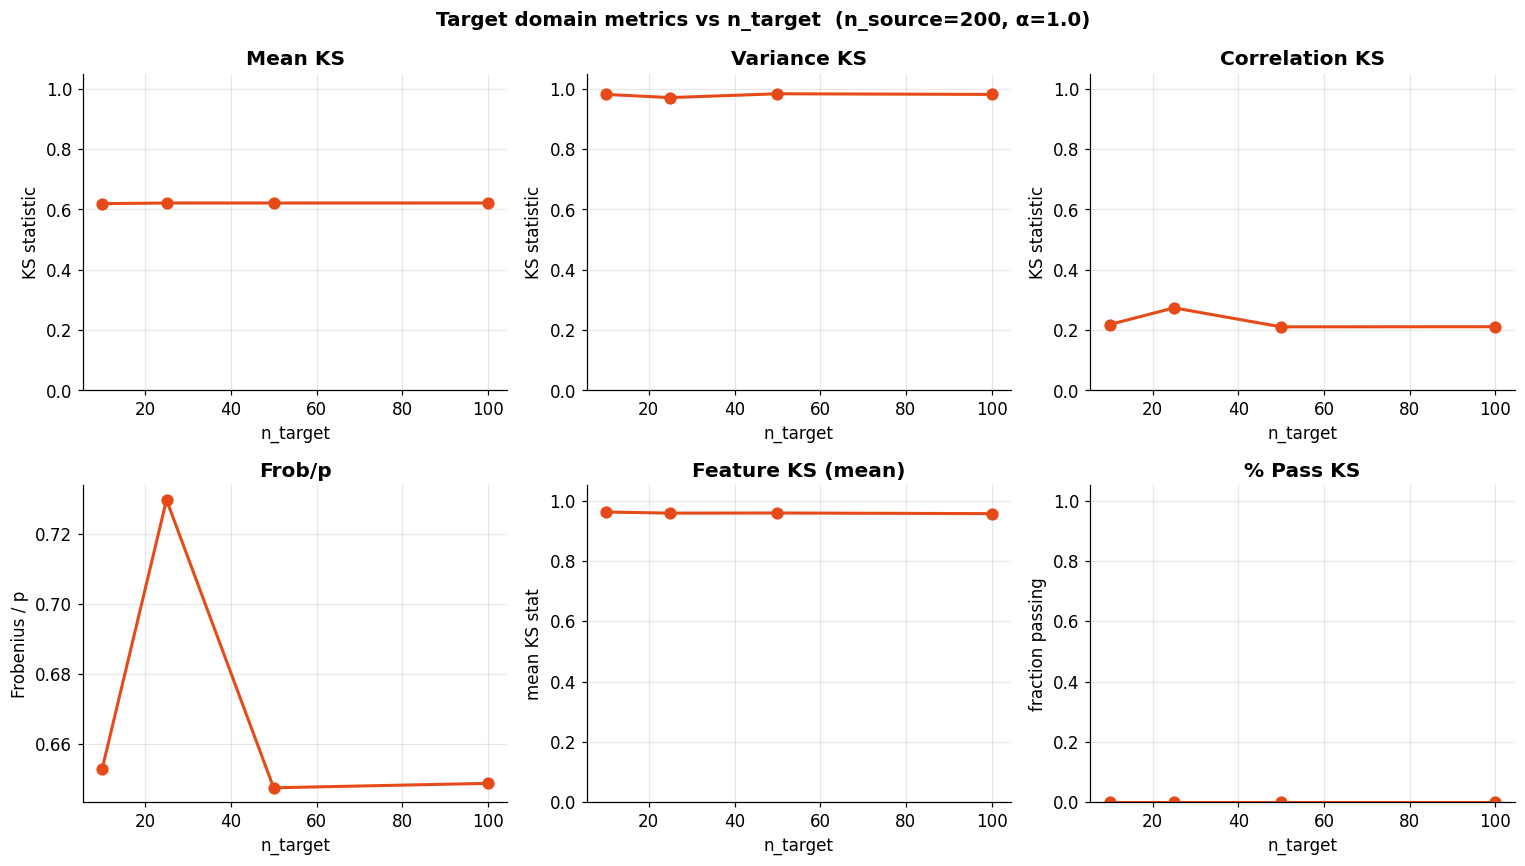

In [14]:
metrics_cfg = [
    ("mean_ks",      "Mean KS",           "KS statistic"),
    ("var_ks",       "Variance KS",       "KS statistic"),
    ("cor_ks",       "Correlation KS",    "KS statistic"),
    ("frob",         "Frob/p",            "Frobenius / p"),
    ("feat_ks_mean", "Feature KS (mean)", "mean KS stat"),
    ("frac_pass",    "% Pass KS",         "fraction passing"),
]

for ns_fixed in n_source_list:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"Target domain metrics vs n_target  (n_source={ns_fixed}, α={FIDELITY_ALPHA})",
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for ax_idx, (key, title, ylabel) in enumerate(metrics_cfg):
        ax = axes[ax_idx]
        sub = [r for r in records if r["n_source"] == ns_fixed]
        xs = [r["n_target"]        for r in sub]
        ys = [r["tgt_stats"][key]  for r in sub]
        ax.plot(xs, ys, '-o', lw=2, ms=7, color=PALETTE["target"])
        ax.set_xlabel("n_target")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        if key in ("mean_ks", "var_ks", "cor_ks", "feat_ks_mean", "frac_pass"):
            ax.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

## Source vs Target fidelity comparison

Direct comparison of how well each domain is captured across all scenarios.

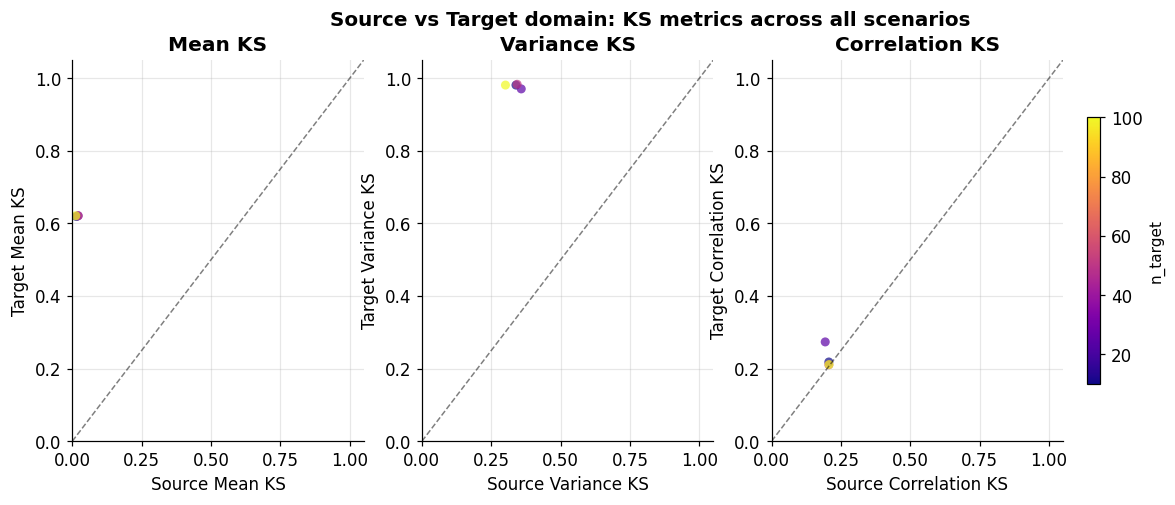

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Source vs Target domain: KS metrics across all scenarios",
             fontsize=13, fontweight='bold')

for ax, (key, title, _) in zip(axes, metrics_cfg[:3]):
    src_vals = [r["src_stats"][key] for r in records]
    tgt_vals = [r["tgt_stats"][key] for r in records]

    sc = ax.scatter(src_vals, tgt_vals, alpha=0.7, s=35,
                    c=[r["n_target"] for r in records],
                    cmap='plasma', edgecolors='none')
    lims = [0, 1.05]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"Source {title}")
    ax.set_ylabel(f"Target {title}")
    ax.set_title(title, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='plasma',
                            norm=plt.Normalize(min(n_target_list), max(n_target_list)))
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02)
cbar.set_label("n_target", fontsize=10)

plt.show()

---
## Part 2: Design validation

The following sections check that the shared-loadings simulation design has the
structural properties required for a valid transfer learning benchmark.

These checks are **independent of real-data fidelity**: a simulation can match
real-data statistics perfectly but still be a poor TL benchmark if, e.g., there is
no domain shift or the response is incoherent with the target features.

### 2.1 Domain shift validation

The target PC score distribution is an α-interpolation between source and target:

µ_T(α) = (1 − α) µ_S + α µ_T_observed,   Σ_T(α) = (1 − α) Σ_S + α Σ_T_observed

At **α = 0** the synthetic target is drawn from the same distribution as source — ‖µ_T − µ_S‖ ≈ 0.  
At **α = 1** the full observed domain shift is reproduced — ‖µ_T − µ_S‖ is large.

The 4 active PCs are chosen by an activity score (source variance / (1 + normalised shift²)) that deprioritises
any PC dominated by between-domain mean difference, so the bars below reflect the *usable* shift
rather than a raw spike in one PC.

In [16]:
# Part 2 fixed scenario: n_source=200, n_target=50, SNR=1
P2_N_SOURCE = 200
P2_N_TARGET = 50
P2_SNR      = 1

ALPHA_COLORS = {0.0: PALETTE["source"], 1.0: PALETTE["target"]}
ALPHA_LABELS = {0.0: "α=0 (no shift)", 1.0: "α=1 (full shift)"}

part2 = {}
for alpha in [0.0, 1.0]:
    src_feat, tgt_feat, src_sc, tgt_sc = generate_synth_data_pca(
        source_data=source_real,
        target_data=target_real,
        n_output_samps_source=P2_N_SOURCE,
        n_output_samps_target=P2_N_TARGET,
        alpha=alpha,
    )
    part2[alpha] = {
        "synth_src":  src_feat,
        "synth_tgt":  tgt_feat,
        "src_scores": src_sc,
        "tgt_scores": tgt_sc,
        "mu_shift":   float(np.linalg.norm(tgt_sc.mean(axis=0))),
        "label":      f"n_src={P2_N_SOURCE}, n_tgt={P2_N_TARGET}, α={alpha}",
    }
    print(f"α={alpha}: ‖µ_T‖ = {part2[alpha]['mu_shift']:.3f}")

α=0.0: ‖µ_T‖ = 1.606
α=1.0: ‖µ_T‖ = 12.883


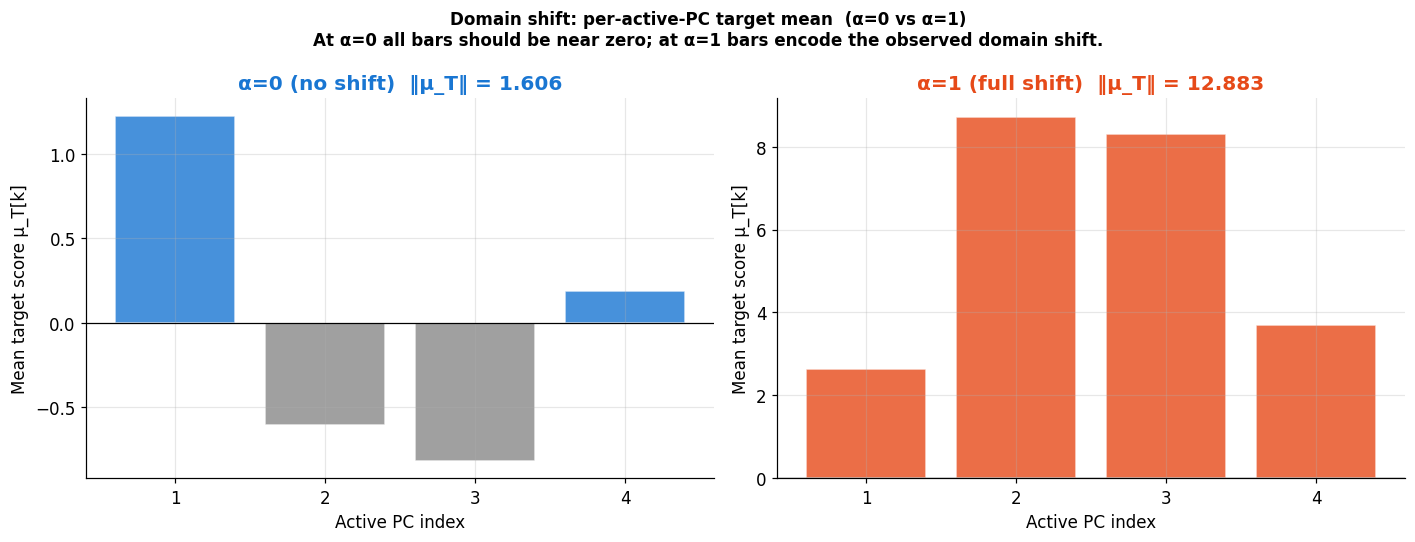

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Domain shift: per-active-PC target mean  (α=0 vs α=1)\n"
    "At α=0 all bars should be near zero; at α=1 bars encode the observed domain shift.",
    fontsize=11, fontweight="bold"
)

for ax, alpha in zip(axes, [0.0, 1.0]):
    p2 = part2[alpha]
    n_show = p2["tgt_scores"].shape[1]
    pc_means = p2["tgt_scores"].mean(axis=0)
    colors = [ALPHA_COLORS[alpha] if v >= 0 else "#888888" for v in pc_means]
    ax.bar(range(1, n_show + 1), pc_means, color=colors, alpha=0.8, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("Active PC index")
    ax.set_ylabel("Mean target score µ_T[k]")
    ax.set_title(
        f"{ALPHA_LABELS[alpha]}  ‖µ_T‖ = {p2['mu_shift']:.3f}",
        fontweight="bold", color=ALPHA_COLORS[alpha]
    )
    ax.set_xticks(range(1, n_show + 1))

plt.tight_layout()
plt.show()

### 2.2 Source and target scores in shared active-PC space

The 4 active PCs are selected by activity score (source variance / (1 + normalised shift²)), so any PC
dominated by a single between-domain mean spike is deprioritised.

At **α = 0** source and target should overlap completely — the two clouds are drawn from the same
Gaussian. At **α = 1** the target cloud is displaced by µ_T(1).

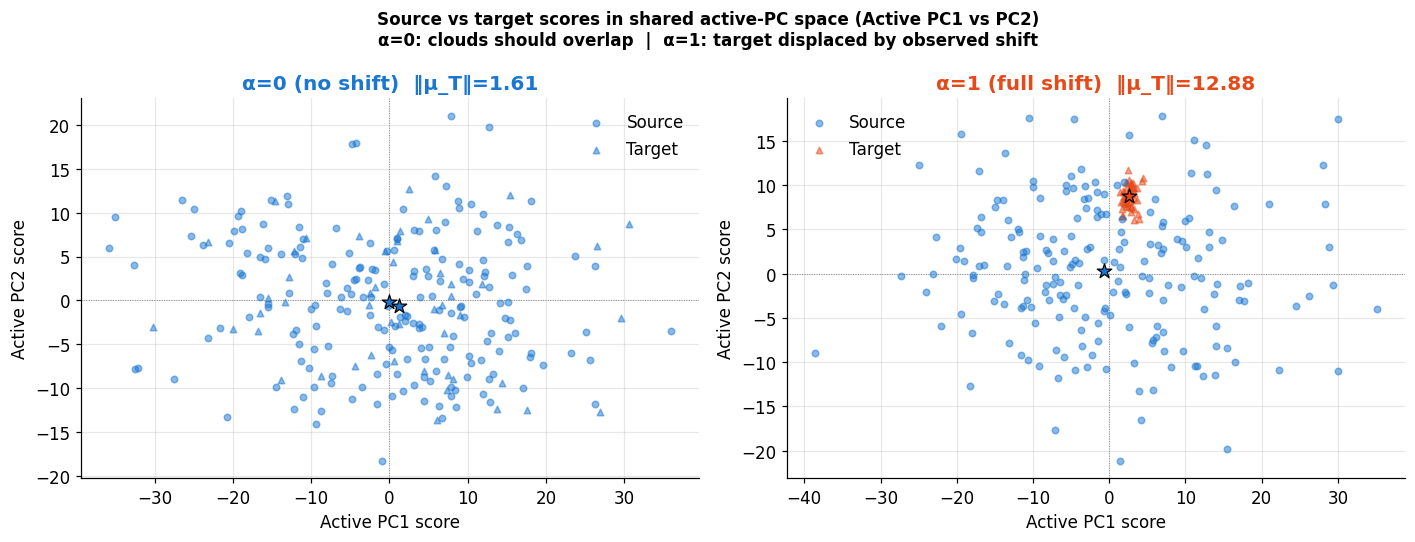

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Source vs target scores in shared active-PC space (Active PC1 vs PC2)\n"
    "α=0: clouds should overlap  |  α=1: target displaced by observed shift",
    fontsize=11, fontweight="bold"
)

for ax, alpha in zip(axes, [0.0, 1.0]):
    p2 = part2[alpha]
    src_sc = p2["src_scores"]
    tgt_sc = p2["tgt_scores"]

    ax.scatter(src_sc[:, 0], src_sc[:, 1],
               color=PALETTE["source"], alpha=0.5, s=18, label="Source", zorder=3)
    ax.scatter(tgt_sc[:, 0], tgt_sc[:, 1],
               color=ALPHA_COLORS[alpha], alpha=0.5, s=18, marker="^", label="Target", zorder=2)

    src_mu = src_sc.mean(axis=0)
    tgt_mu = tgt_sc.mean(axis=0)
    ax.scatter(src_mu[0], src_mu[1], color=PALETTE["source"],
               s=100, marker="*", edgecolors="black", lw=0.8, zorder=5)
    ax.scatter(tgt_mu[0], tgt_mu[1], color=ALPHA_COLORS[alpha],
               s=100, marker="*", edgecolors="black", lw=0.8, zorder=5)

    ax.set_xlabel("Active PC1 score")
    ax.set_ylabel("Active PC2 score")
    ax.set_title(f"{ALPHA_LABELS[alpha]}  ‖µ_T‖={p2['mu_shift']:.2f}",
                 fontweight="bold", color=ALPHA_COLORS[alpha])
    ax.legend(frameon=False)
    ax.axhline(0, color="gray", lw=0.6, ls=":")
    ax.axvline(0, color="gray", lw=0.6, ls=":")

plt.tight_layout()
plt.show()

### 2.3 Response coherence

Verifies that the response is non-trivially predictable from synthetic features in **both** domains for
**both** α values, using SNR = 1.

**Continuous** — linear regression; metric is R²:

| Metric | Expectation |
|---|---|
| R²(src, in-sample) | High for both α — sanity check |
| R²(tgt, cross-domain) | α=0: near in-sample (no shift); α=1: lower due to domain shift |
| R²(tgt, self) | Upper bound for both α |

**Categorical** — logistic regression; metric is AUC (γ = 1.0):

| Metric | Expectation |
|---|---|
| AUC(src) | High for both α — sanity check |
| AUC(xfer) | α=0: near AUC(self); α=1: lower due to shift |
| AUC(self) | Upper bound for both α |
| Class balance | α=0: ~50% both domains; α=1: target may be imbalanced |

linear       α=0.0: R²(in-sample)=0.525  R²(cross-domain)=0.676  R²(self)=0.707
linear       α=1.0: R²(in-sample)=0.469  R²(cross-domain)=0.498  R²(self)=0.586
interaction  α=0.0: R²(in-sample)=0.434  R²(cross-domain)=0.484  R²(self)=0.493
interaction  α=1.0: R²(in-sample)=0.463  R²(cross-domain)=-0.745  R²(self)=0.538
nonlinear    α=0.0: R²(in-sample)=0.372  R²(cross-domain)=0.380  R²(self)=0.448
nonlinear    α=1.0: R²(in-sample)=0.441  R²(cross-domain)=-14.844  R²(self)=0.479


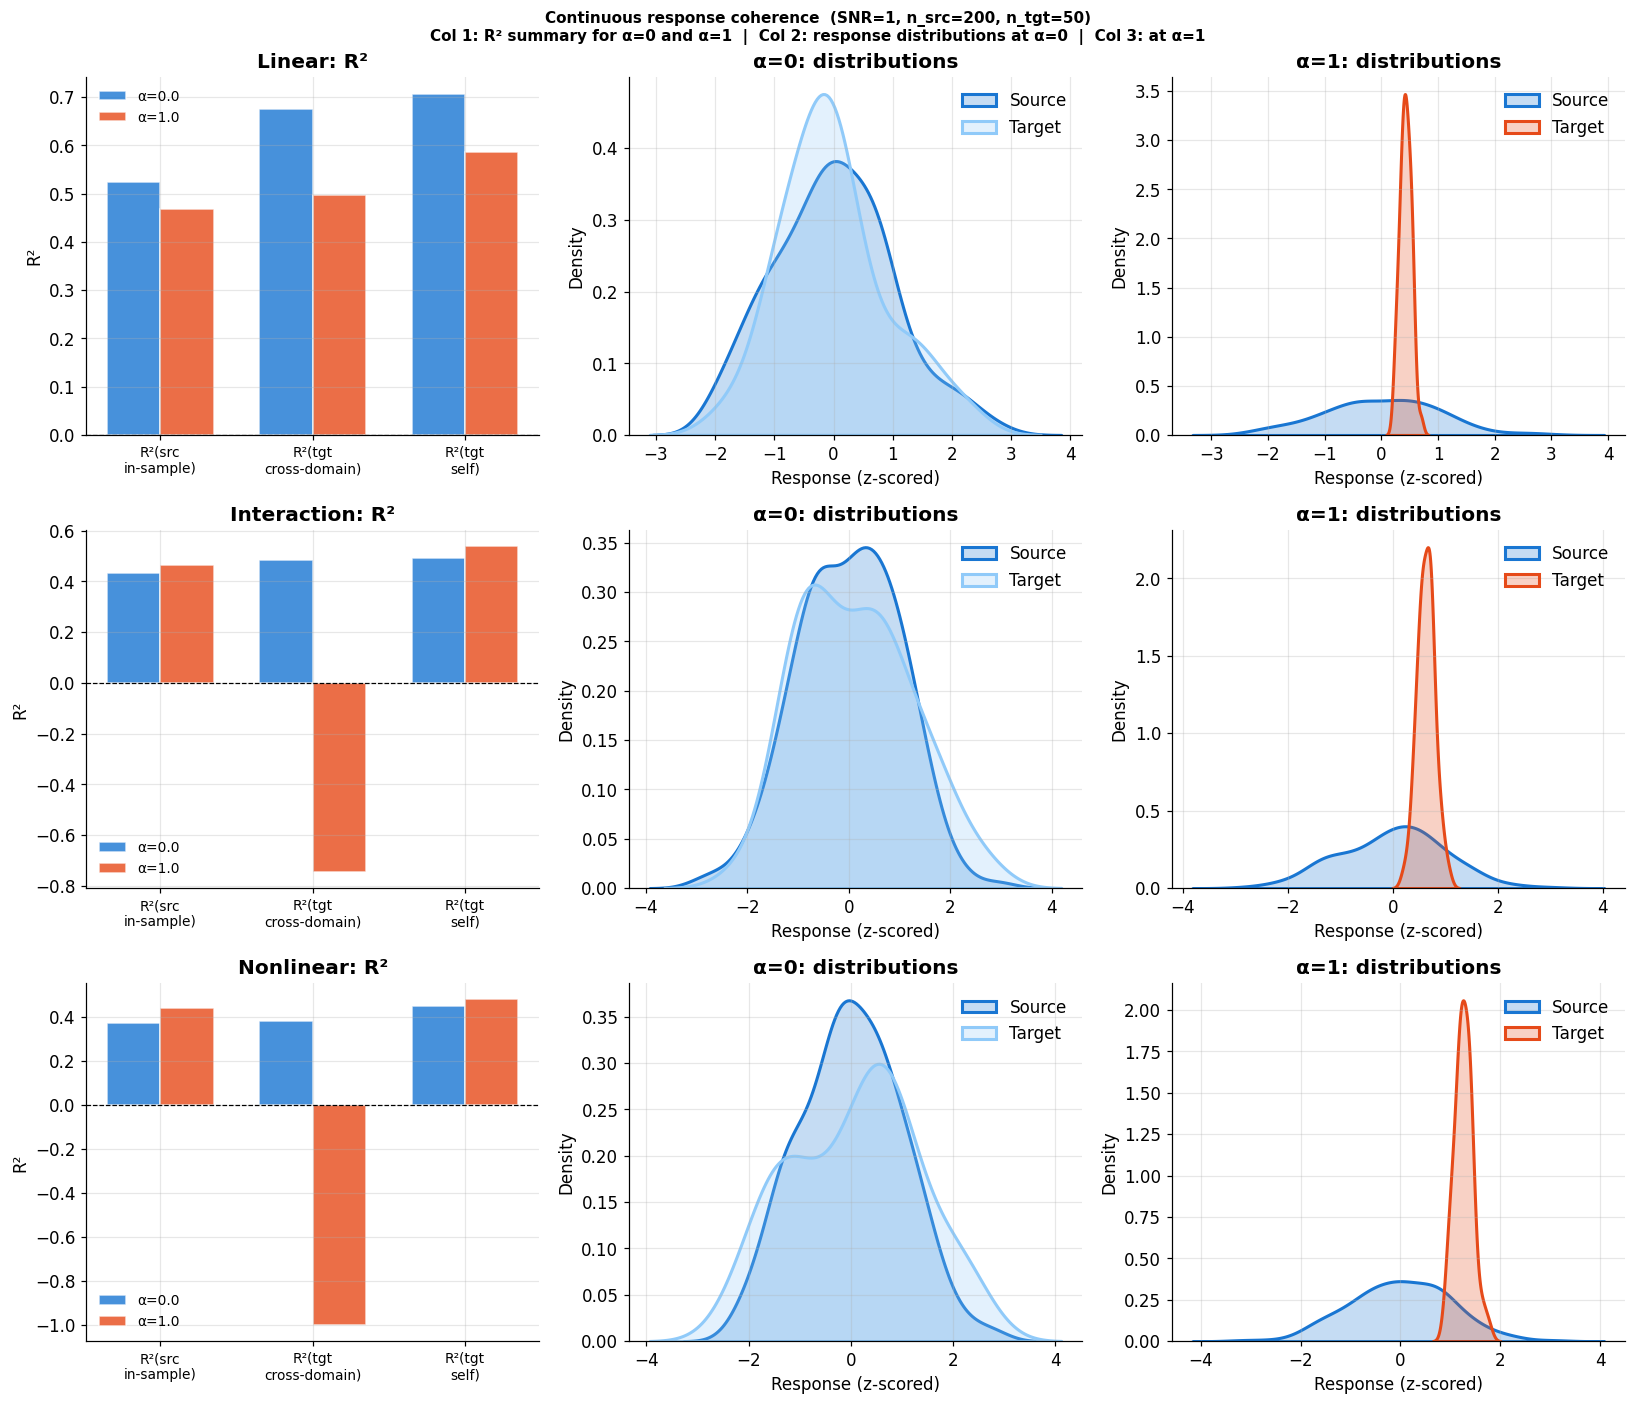

In [19]:
COMPLEXITIES = ["linear", "interaction", "nonlinear"]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle(
    f"Continuous response coherence  (SNR={P2_SNR}, n_src={P2_N_SOURCE}, n_tgt={P2_N_TARGET})\n"
    "Col 1: R² summary for α=0 and α=1  |  Col 2: response distributions at α=0  |  Col 3: at α=1",
    fontsize=10, fontweight="bold"
)

for row_idx, complexity in enumerate(COMPLEXITIES):
    r2_vals   = {}
    resp_data = {}

    for alpha in [0.0, 1.0]:
        p2 = part2[alpha]
        src_df, tgt_df, _ = generate_pca_response(
            source_features=p2["synth_src"],
            target_features=p2["synth_tgt"],
            complexity=complexity,
            is_categorical=False,
            snr=P2_SNR,
            source_scores=p2["src_scores"],
            target_scores=p2["tgt_scores"],
        )

        resp_mean = src_df["response"].mean()
        resp_sd   = src_df["response"].std(ddof=1)
        src_resp  = ((src_df["response"] - resp_mean) / resp_sd).values if resp_sd > 1e-10 else src_df["response"].values
        tgt_resp  = ((tgt_df["response"] - resp_mean) / resp_sd).values if resp_sd > 1e-10 else tgt_df["response"].values

        lr  = LinearRegression().fit(p2["synth_src"].values, src_resp)
        r2_insample = r2_score(src_resp, lr.predict(p2["synth_src"].values))
        r2_xfer     = r2_score(tgt_resp, lr.predict(p2["synth_tgt"].values))
        lr_tgt      = LinearRegression().fit(p2["synth_tgt"].values, tgt_resp)
        r2_self     = r2_score(tgt_resp, lr_tgt.predict(p2["synth_tgt"].values))

        r2_vals[alpha]   = (r2_insample, r2_xfer, r2_self)
        resp_data[alpha] = (src_resp, tgt_resp)

    # — Col 0: grouped R² bar chart —
    ax = axes[row_idx, 0]
    x     = np.arange(3)
    width = 0.35
    xlabels = ["R²(src\nin-sample)", "R²(tgt\ncross-domain)", "R²(tgt\nself)"]
    for i, alpha in enumerate([0.0, 1.0]):
        vals = [max(v, -1.0) for v in r2_vals[alpha]]   # clip for display
        ax.bar(x + i * width, vals, width, label=f"α={alpha}",
               color=ALPHA_COLORS[alpha], alpha=0.8, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_ylabel("R²")
    ax.set_title(f"{complexity.capitalize()}: R²", fontweight="bold")
    ax.legend(frameon=False, fontsize=9)

    # — Col 1: response distributions at α=0 —
    ax = axes[row_idx, 1]
    src_r, tgt_r = resp_data[0.0]
    sns.kdeplot(src_r, ax=ax, color=PALETTE["source"], lw=2,
                label="Source", fill=True, alpha=0.25)
    sns.kdeplot(tgt_r, ax=ax, color="#90CAF9", lw=2,
                label="Target", fill=True, alpha=0.25)
    ax.set_xlabel("Response (z-scored)")
    ax.set_ylabel("Density")
    ax.set_title("α=0: distributions", fontweight="bold")
    ax.legend(frameon=False)

    # — Col 2: response distributions at α=1 —
    ax = axes[row_idx, 2]
    src_r, tgt_r = resp_data[1.0]
    sns.kdeplot(src_r, ax=ax, color=PALETTE["source"], lw=2,
                label="Source", fill=True, alpha=0.25)
    sns.kdeplot(tgt_r, ax=ax, color=PALETTE["target"], lw=2,
                label="Target", fill=True, alpha=0.25)
    ax.set_xlabel("Response (z-scored)")
    ax.set_ylabel("Density")
    ax.set_title("α=1: distributions", fontweight="bold")
    ax.legend(frameon=False)

    for alpha in [0.0, 1.0]:
        ri, rx, rs = r2_vals[alpha]
        print(f"{complexity:12s} α={alpha}: R²(in-sample)={ri:.3f}  "
              f"R²(cross-domain)={rx:.3f}  R²(self)={rs:.3f}")

plt.tight_layout()
plt.show()

linear       α=0.0: src_AUC=0.799  xfer_AUC=0.717  self_AUC=0.744  P(Y=1): src=0.53 tgt=0.50
linear       α=1.0: src_AUC=0.755  xfer_AUC=0.470  self_AUC=0.575  P(Y=1): src=0.57 tgt=0.54
interaction  α=0.0: src_AUC=0.740  xfer_AUC=0.618  self_AUC=0.683  P(Y=1): src=0.46 tgt=0.46
interaction  α=1.0: src_AUC=0.692  xfer_AUC=0.577  self_AUC=0.696  P(Y=1): src=0.44 tgt=0.72
nonlinear    α=0.0: src_AUC=0.746  xfer_AUC=0.846  self_AUC=0.872  P(Y=1): src=0.48 tgt=0.58
nonlinear    α=1.0: src_AUC=0.689  xfer_AUC=0.524  self_AUC=0.679  P(Y=1): src=0.51 tgt=0.84


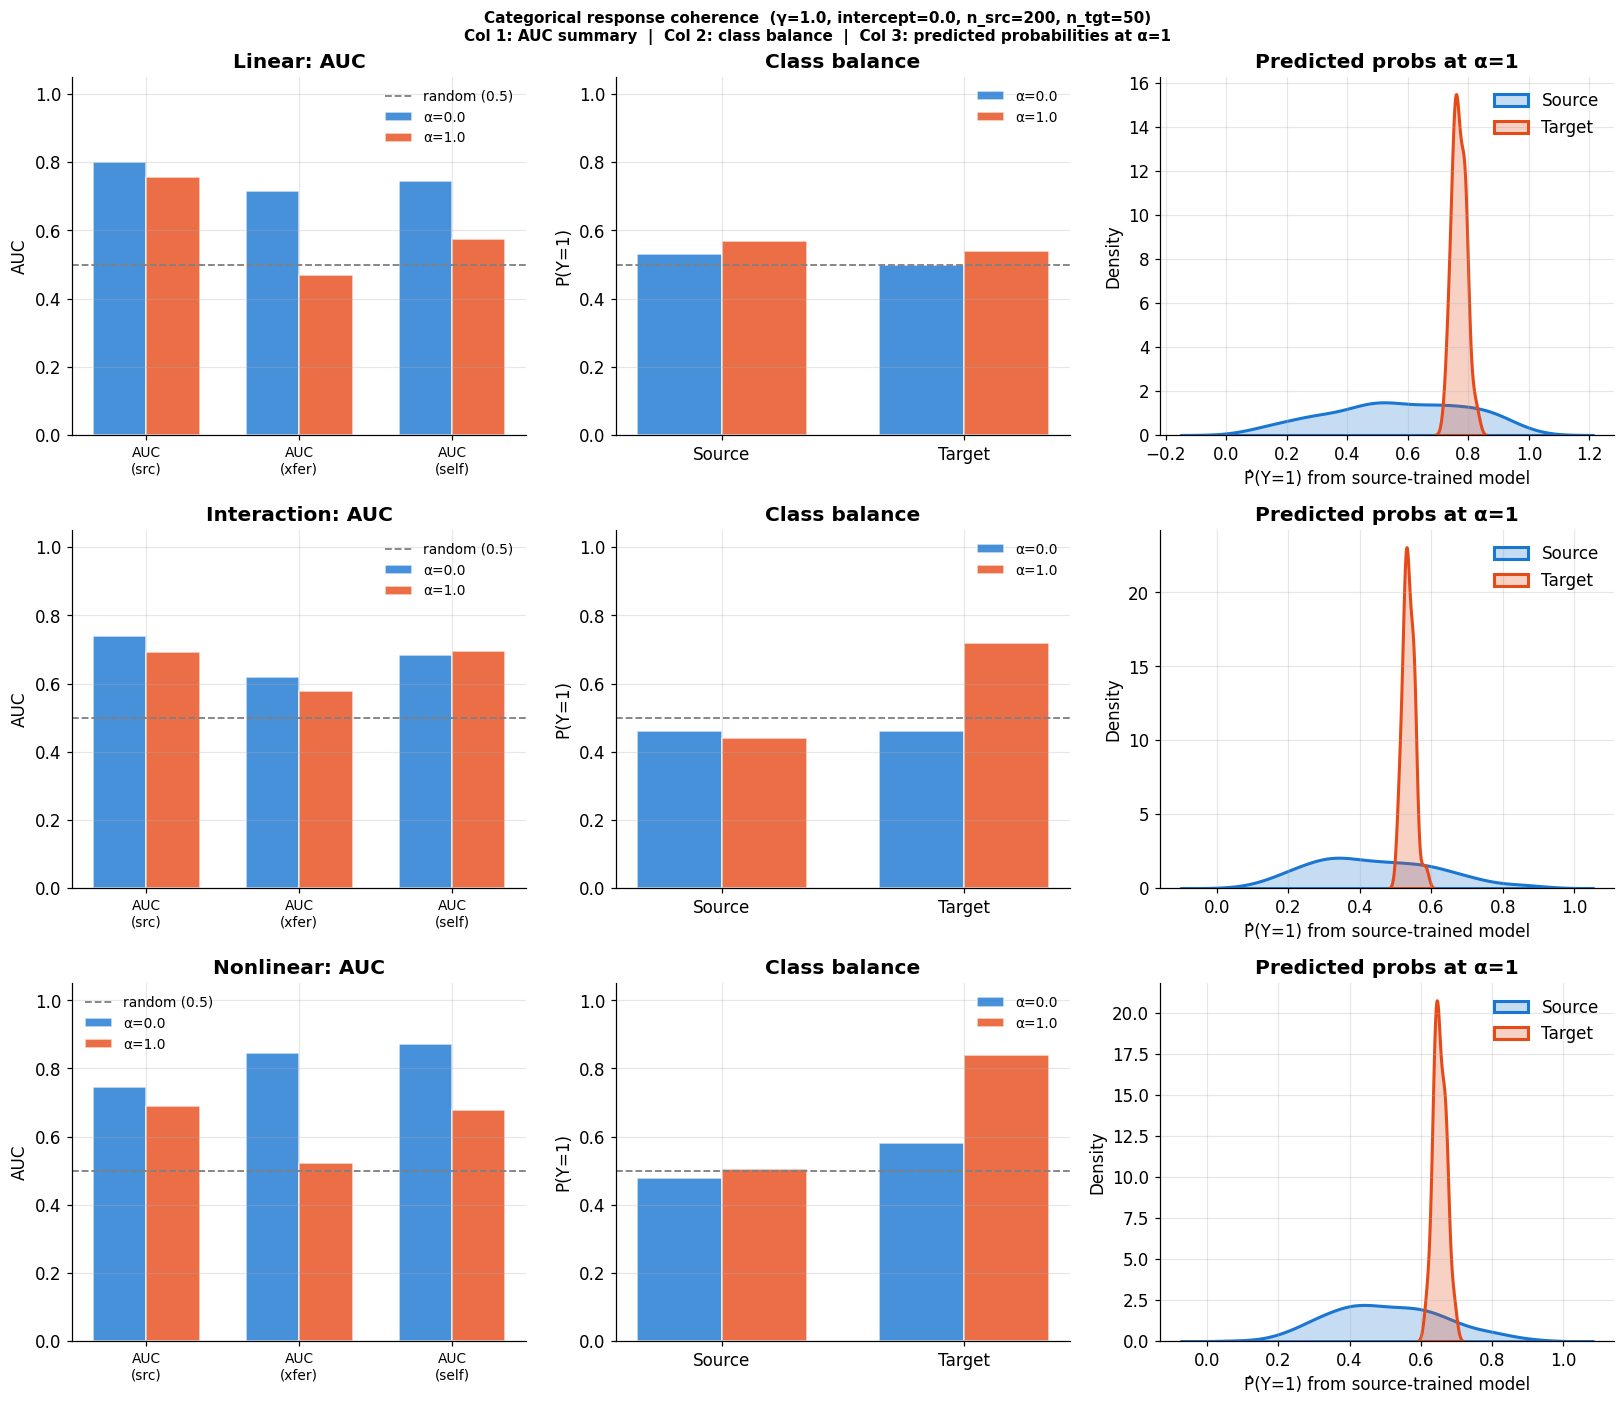

In [20]:
COMPLEXITIES = ["linear", "interaction", "nonlinear"]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle(
    f"Categorical response coherence  (γ=1.0, intercept=0.0, n_src={P2_N_SOURCE}, n_tgt={P2_N_TARGET})\n"
    "Col 1: AUC summary  |  Col 2: class balance  |  Col 3: predicted probabilities at α=1",
    fontsize=10, fontweight="bold"
)

for row_idx, complexity in enumerate(COMPLEXITIES):
    auc_vals      = {}
    balance_vals  = {}
    src_prob_vals = {}
    tgt_prob_vals = {}

    for alpha in [0.0, 1.0]:
        p2 = part2[alpha]
        src_df, tgt_df, _ = generate_pca_response(
            source_features=p2["synth_src"],
            target_features=p2["synth_tgt"],
            complexity=complexity,
            is_categorical=True,
            source_scores=p2["src_scores"],
            target_scores=p2["tgt_scores"],
        )

        src_y = src_df["response"].values
        tgt_y = tgt_df["response"].values
        src_n_cls = len(np.unique(src_y))
        tgt_n_cls = len(np.unique(tgt_y))

        if src_n_cls > 1:
            clf = LogisticRegression(max_iter=1000, random_state=0)
            clf.fit(p2["synth_src"].values, src_y)
            src_prob     = clf.predict_proba(p2["synth_src"].values)[:, 1]
            tgt_prob     = clf.predict_proba(p2["synth_tgt"].values)[:, 1]
            src_auc      = roc_auc_score(src_y, src_prob)
            tgt_auc_xfer = roc_auc_score(tgt_y, tgt_prob) if tgt_n_cls > 1 else float("nan")
        else:
            src_prob = np.full(len(src_y), float("nan"))
            tgt_prob = np.full(len(tgt_y), float("nan"))
            src_auc  = float("nan")
            tgt_auc_xfer = float("nan")

        if tgt_n_cls > 1:
            clf_tgt      = LogisticRegression(max_iter=1000, random_state=0)
            clf_tgt.fit(p2["synth_tgt"].values, tgt_y)
            tgt_auc_self = roc_auc_score(tgt_y, clf_tgt.predict_proba(p2["synth_tgt"].values)[:, 1])
        else:
            tgt_auc_self = float("nan")

        auc_vals[alpha]      = (src_auc, tgt_auc_xfer, tgt_auc_self)
        balance_vals[alpha]  = (src_y.mean(), tgt_y.mean())
        src_prob_vals[alpha] = src_prob
        tgt_prob_vals[alpha] = tgt_prob

    # — Col 0: grouped AUC bar chart —
    ax = axes[row_idx, 0]
    x, width = np.arange(3), 0.35
    auc_labels = ["AUC\n(src)", "AUC\n(xfer)", "AUC\n(self)"]
    for i, alpha in enumerate([0.0, 1.0]):
        vals = [v if not np.isnan(v) else 0.0 for v in auc_vals[alpha]]
        ax.bar(x + i * width, vals, width, label=f"α={alpha}",
               color=ALPHA_COLORS[alpha], alpha=0.8, edgecolor="white")
    ax.axhline(0.5, color="gray", lw=1.2, ls="--", label="random (0.5)")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(auc_labels, fontsize=9)
    ax.set_ylabel("AUC")
    ax.set_title(f"{complexity.capitalize()}: AUC", fontweight="bold")
    ax.legend(frameon=False, fontsize=9)

    # — Col 1: class balance for both alphas —
    ax = axes[row_idx, 1]
    x_bal, w_bal = np.arange(2), 0.35
    for i, alpha in enumerate([0.0, 1.0]):
        src_bal, tgt_bal = balance_vals[alpha]
        ax.bar(x_bal + i * w_bal, [src_bal, tgt_bal], w_bal,
               label=f"α={alpha}", color=ALPHA_COLORS[alpha], alpha=0.8, edgecolor="white")
    ax.set_xticks(x_bal + w_bal / 2)
    ax.set_xticklabels(["Source", "Target"])
    ax.axhline(0.5, color="gray", lw=1.2, ls="--")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("P(Y=1)")
    ax.set_title("Class balance", fontweight="bold")
    ax.legend(frameon=False, fontsize=9)

    # — Col 2: predicted probability distributions at α=1 —
    ax = axes[row_idx, 2]
    sp = src_prob_vals[1.0]
    tp = tgt_prob_vals[1.0]
    if not np.any(np.isnan(sp)):
        sns.kdeplot(sp, ax=ax, color=PALETTE["source"], lw=2,
                    label="Source", fill=True, alpha=0.25)
    if not np.any(np.isnan(tp)):
        sns.kdeplot(tp, ax=ax, color=PALETTE["target"], lw=2,
                    label="Target", fill=True, alpha=0.25)
    ax.set_xlabel("P̂(Y=1) from source-trained model")
    ax.set_ylabel("Density")
    ax.set_title("Predicted probs at α=1", fontweight="bold")
    ax.legend(frameon=False)

    for alpha in [0.0, 1.0]:
        sa, ta, ts = auc_vals[alpha]
        sb, tb    = balance_vals[alpha]
        print(f"{complexity:12s} α={alpha}: src_AUC={sa:.3f}  xfer_AUC={ta:.3f}  "
              f"self_AUC={ts:.3f}  P(Y=1): src={sb:.2f} tgt={tb:.2f}")

plt.tight_layout()
plt.show()